# 201 — Re-evaluate baseline Pareto designs under transmissivity scenarios

**Purpose:** This notebook takes the already-validated baseline fish-dollars Pareto designs and re-evaluates those same pumping designs under different transmissivity assumptions.

This is the first actual uncertainty-analysis notebook after validation.

The main project metrics are:

- **total pumping**, reported as raw pumping and effective pumping after the fish-dollars 70% cutoff
- **depletion**, using `lpr:total_combined:bdpl`
- **streamflow**, calculated as:

$$
Q_{stream} = Q_{historic} - Q_{depletion}
$$

where the default historical/reference streamflow is:

$$
Q_{historic} = 8.6 \text{ cfs}
$$

The fish-dollars objectives (`ag_receipts`, `fish_prob`) are still saved as diagnostics, but the main figures focus on **pumping vs depletion** and **pumping vs streamflow**.

## 1) User settings

Run this notebook from:

`/workspaces/LPR_redux/LPR_pycap_opt/notebooks`

Only edit this first code cell if your folder names or desired T scenarios change.

In [1]:
from pathlib import Path
import sys
import os
import copy
import importlib.util
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User settings
# -----------------------------
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"

# Use all final-generation feasible front-1 members by default.
# To make a fast smoke test, set N_TEST_MEMBERS = 5 or 10.
N_TEST_MEMBERS = None

# Conversion used in older postprocessing notebooks for pumping diagnostics.
GPM2CFS = 0.002228

# Hydrologic tradeoff settings for this project.
HISTORIC_STREAMFLOW_CFS = 8.6
DEPLETION_OBS_NAME = "lpr:total_combined:bdpl"

# Main x-axis for hydrologic plots.
# Because the fish-dollars forward model shuts down farms/wells below the 70% threshold,
# the effective pumping is the pumping actually passed through the objective calculation.
PUMPING_COLUMN_FOR_HYDRO_PLOTS = "effective_total_pumping_cfs"

# T scenarios to evaluate.
# label: multiplier on baseline T
T_SCENARIOS = {
    "T_minus_10pct": 0.90,
    "baseline_T": 1.00,
    "T_plus_10pct": 1.10,
}

# -----------------------------
# Robust repo paths
# -----------------------------
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
RUN_DIR = PROJECT_DIR / "pycap_runs" / "pycap_pest" / f"run_{RUN_NAME}"
SCRIPTS_DIR = PROJECT_DIR / "scripts"
OUTPUT_DIR = NOTEBOOK_DIR / "project_output" / "201_reevaluate_baseline_pareto_under_T_scenarios"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("RUN_DIR:", RUN_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

NOTEBOOK_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
RUN_DIR: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios


## 2) Load the original fish-dollars forward model

We use the original fish-dollars script as the source of truth. That keeps the re-evaluation consistent with the actual MOU run.

This matters because the fish-dollars script includes details that are easy to accidentally miss, especially the low-pumping cutoff logic and the fish/agriculture calculations.

In [2]:
def import_python_file(module_name: str, file_path: Path):
    """Import a Python file by path without permanently changing the repo."""
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find Python file: {file_path}")
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


# Prefer the copy inside the run folder because that is exactly what the MOU run used.
# Fall back to ../scripts if needed.
candidate_scripts = [
    RUN_DIR / "run_pycap_standalone_opt_mou_fish_dollars.py",
    SCRIPTS_DIR / "run_pycap_standalone_opt_mou_fish_dollars.py",
]

for candidate in candidate_scripts:
    if candidate.exists():
        FISH_DOLLARS_SCRIPT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find run_pycap_standalone_opt_mou_fish_dollars.py "
        "in the run folder or scripts folder."
    )

fish_dollars = import_python_file("fish_dollars_forward_201", FISH_DOLLARS_SCRIPT)
print("Using fish-dollars source-of-truth script:")
print(FISH_DOLLARS_SCRIPT)

Using fish-dollars source-of-truth script:
/workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01/run_pycap_standalone_opt_mou_fish_dollars.py


## 3) Helper functions

In [3]:
def read_pareto_archive_summary(run_name: str, run_dir: Path) -> pd.DataFrame:
    pareto_file = Path(run_dir) / f"{run_name}.pareto.archive.summary.csv.zip"
    if not pareto_file.exists():
        raise FileNotFoundError(f"Missing Pareto archive summary: {pareto_file}")
    df = pd.read_csv(pareto_file)
    df["member"] = df["member"].astype(str)
    return df


def select_final_feasible_front1(pareto_df: pd.DataFrame, n_test_members=None) -> pd.DataFrame:
    required = {"member", "generation", "nsga2_front", "is_feasible", "ag_receipts", "fish_prob"}
    missing = required - set(pareto_df.columns)
    if missing:
        raise KeyError(f"Pareto archive summary is missing required columns: {sorted(missing)}")

    df = pareto_df.loc[
        (pareto_df["nsga2_front"] == 1) &
        (pareto_df["is_feasible"] == 1)
    ].copy()

    final_generation = df["generation"].max()
    df = df.loc[df["generation"] == final_generation].copy()
    df["member"] = df["member"].astype(str)

    if n_test_members is not None:
        df = df.head(int(n_test_members)).copy()

    if df.empty:
        raise ValueError("No final-generation feasible front-1 members found.")

    return df


def load_decision_variable_population(run_dir: Path) -> pd.DataFrame:
    """
    Load saved decision-variable populations from the MOU run.

    We intentionally include both archive and non-archive dv_pop files, plus initial_dvpop.csv
    when present, because final Pareto members can come from any saved population.
    """
    run_dir = Path(run_dir)
    dv_files = sorted(run_dir.glob("*dv_pop.csv.zip"))
    frames = []

    for f in dv_files:
        try:
            frames.append(pd.read_csv(f, index_col=0))
        except Exception as err:
            print(f"Warning: could not read {f.name}: {err}")

    init_file = run_dir / "initial_dvpop.csv"
    if init_file.exists():
        frames.append(pd.read_csv(init_file, index_col=0))

    if not frames:
        raise FileNotFoundError(f"No dv_pop csv files were found in {run_dir}")

    dv_df = pd.concat(frames, axis=0)
    dv_df.index = dv_df.index.astype(str)
    dv_df = dv_df[~dv_df.index.duplicated(keep="first")]
    return dv_df


def get_q_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if str(c).lower().endswith("__q") or "_q" in str(c).lower()]


def effective_q_after_fish_dollars_cutoff(q_row: pd.Series, receipts: pd.DataFrame) -> pd.Series:
    """
    Reproduce the fish-dollars pumping cutoff used by the original forward model:
    if a pumping decision is <= 70% of baseline parval1, set that Q to zero.
    """
    q = q_row.copy()
    q.index = [str(i).lower() for i in q.index]
    q = q.loc[q.index.str.contains("_q")]
    local_receipts = receipts.loc[q.index]
    q.loc[q <= 0.7 * local_receipts.parval1] = 0.0
    return q


def make_initial_dict_with_T(initial_dict_master, t_factor: float):
    """
    Return a deep-copied project dictionary with project_properties['T'] multiplied by t_factor.

    This is the key uncertainty injection step for known T error.
    """
    initial_dict = copy.deepcopy(initial_dict_master)

    if "project_properties" not in initial_dict:
        raise KeyError("initial_dict does not contain 'project_properties'.")

    if "T" not in initial_dict["project_properties"]:
        raise KeyError("initial_dict['project_properties'] does not contain 'T'.")

    base_T = float(initial_dict_master["project_properties"]["T"])
    initial_dict["project_properties"]["T"] = base_T * float(t_factor)
    return initial_dict


def run_original_fish_dollars_get_results(
    q_row: pd.Series,
    initial_dict_master,
    bdplobs,
    fishcurve,
    ref_flow,
    receipts,
    t_factor: float = 1.0,
):
    """
    Call the original fish-dollars get_results() function after applying a T multiplier.

    We pass a deep copy of the initial dictionary each time to avoid cross-run mutation.
    """
    q_row = q_row.copy()
    q_row.index = [str(i).lower() for i in q_row.index]

    initial_dict_t = make_initial_dict_with_T(initial_dict_master, t_factor)

    obsnames = [i.split("!")[1].lower() for i in open(RUN_DIR / "allobs.out.ins", "r").readlines()[1:]]

    result = fish_dollars.get_results(
        q_row,
        obsnames,
        initial_dict_t,
        bdplobs,
        fishcurve,
        ref_flow,
        receipts,
        write_csv=False,
    )
    return result

## 4) Load source data

This loads the original PyCap project dictionary, baseline depletion observations, fish curve and agricultural receipt tables, the baseline Pareto archive, and the saved decision-variable populations.

In [4]:
# The original instantiate() function uses relative paths, so run it from RUN_DIR.
original_cwd = Path.cwd()
os.chdir(RUN_DIR)
try:
    initial_dict_master, bdplobs, fishcurve, ref_flow, receipts = fish_dollars.instantiate()
finally:
    os.chdir(original_cwd)

pareto_archive = read_pareto_archive_summary(RUN_NAME, RUN_DIR)
pareto_final = select_final_feasible_front1(pareto_archive, n_test_members=N_TEST_MEMBERS)
dv_df = load_decision_variable_population(RUN_DIR)

q_cols = get_q_columns(dv_df)
missing_members = sorted(set(pareto_final["member"]) - set(dv_df.index.astype(str)))

base_T = float(initial_dict_master["project_properties"]["T"])

print("Pareto archive rows:", len(pareto_archive))
print("Final feasible front-1 rows selected:", len(pareto_final))
print("Final generation:", pareto_final["generation"].max())
print("Decision-variable population rows:", len(dv_df))
print("Q columns:", len(q_cols))
print("Baseline T:", base_T)
print("Reference flow from fish-dollars script:", ref_flow)
print("Historical/reference streamflow used in this notebook:", HISTORIC_STREAMFLOW_CFS)
print("Depletion observation:", DEPLETION_OBS_NAME)
print("Missing final members in dv_df:", len(missing_members))

if missing_members:
    raise KeyError(f"Missing Pareto members in dv_pop files. First few: {missing_members[:10]}")

pd.DataFrame({
    "scenario": list(T_SCENARIOS.keys()),
    "T_factor": list(T_SCENARIOS.values()),
    "T_value": [base_T * f for f in T_SCENARIOS.values()],
})

Pareto archive rows: 5669
Final feasible front-1 rows selected: 174
Final generation: 50
Decision-variable population rows: 6528
Q columns: 327
Baseline T: 1700.0
Reference flow from fish-dollars script: 8.6
Historical/reference streamflow used in this notebook: 8.6
Depletion observation: lpr:total_combined:bdpl
Missing final members in dv_df: 0


,scenario,T_factor,T_value
0,T_minus_10pct,0.9,1530.0
1,baseline_T,1.0,1700.0
2,T_plus_10pct,1.1,1870.0


## 5) Re-evaluate baseline Pareto designs under each T scenario

This cell may take a bit because it runs PyCap once per Pareto member per T scenario.

For 174 Pareto members and 3 T scenarios, that is:

$$
174 \times 3 = 522 \text{ forward evaluations}
$$

In [5]:
records = []
errors = []

scenario_items = list(T_SCENARIOS.items())
n_total = len(pareto_final) * len(scenario_items)
counter = 0

for scenario_label, t_factor in scenario_items:
    t_value = base_T * float(t_factor)
    print(f"\nScenario: {scenario_label} | T factor: {t_factor} | T value: {t_value}")

    for i, row in pareto_final.reset_index(drop=True).iterrows():
        counter += 1
        member = str(row["member"])

        if (counter == 1) or (counter % 50 == 0) or (counter == n_total):
            print(f"  Re-evaluating {counter} of {n_total}: scenario={scenario_label}, member={member}")

        q_row = dv_df.loc[member, q_cols].copy()

        try:
            reeval = run_original_fish_dollars_get_results(
                q_row=q_row,
                initial_dict_master=initial_dict_master,
                bdplobs=bdplobs,
                fishcurve=fishcurve,
                ref_flow=ref_flow,
                receipts=receipts,
                t_factor=t_factor,
            )

            q_eff = effective_q_after_fish_dollars_cutoff(q_row, receipts)

            raw_total_pumping_gpm = q_row.sum()
            effective_total_pumping_gpm = q_eff.sum()
            raw_total_pumping_cfs = raw_total_pumping_gpm * GPM2CFS
            effective_total_pumping_cfs = effective_total_pumping_gpm * GPM2CFS

            depletion_cfs = (
                reeval.loc[DEPLETION_OBS_NAME]
                if DEPLETION_OBS_NAME in reeval.index
                else np.nan
            )
            streamflow_cfs = HISTORIC_STREAMFLOW_CFS - depletion_cfs

            records.append({
                "scenario": scenario_label,
                "T_factor": float(t_factor),
                "T_value": t_value,
                "member": member,
                "generation": row["generation"],

                # Original fish-dollars archive objectives from baseline optimization.
                "ag_receipts_archive_baseline": row["ag_receipts"],
                "fish_prob_archive_baseline": row["fish_prob"],

                # Re-evaluated fish-dollars diagnostics under current T scenario.
                "ag_receipts_reeval": reeval.loc["ag_receipts"],
                "fish_prob_reeval": reeval.loc["fish_prob"],

                # Pumping diagnostics; unchanged by T because the design is unchanged.
                "raw_total_pumping_gpm": raw_total_pumping_gpm,
                "raw_total_pumping_cfs": raw_total_pumping_cfs,
                "effective_total_pumping_gpm": effective_total_pumping_gpm,
                "effective_total_pumping_cfs": effective_total_pumping_cfs,

                # Main hydrologic project metrics.
                "depletion_obs_name": DEPLETION_OBS_NAME,
                "depletion_cfs": depletion_cfs,
                "streamflow_cfs": streamflow_cfs,
            })

        except Exception as err:
            errors.append({
                "scenario": scenario_label,
                "T_factor": float(t_factor),
                "member": member,
                "error": repr(err),
                "traceback": traceback.format_exc(),
            })

results_long = pd.DataFrame(records)
error_df = pd.DataFrame(errors)

print("\nSuccessful re-evaluations:", len(results_long))
print("Errors:", len(error_df))

if not error_df.empty:
    display(error_df.head())

results_long.head()


Scenario: T_minus_10pct | T factor: 0.9 | T value: 1530.0
  Re-evaluating 1 of 522: scenario=T_minus_10pct, member=gen=47_member=5907_pso
  Re-evaluating 50 of 522: scenario=T_minus_10pct, member=gen=41_member=5214_pso
  Re-evaluating 100 of 522: scenario=T_minus_10pct, member=gen=47_member=5999_pso
  Re-evaluating 150 of 522: scenario=T_minus_10pct, member=gen=34_member=4241_pso

Scenario: baseline_T | T factor: 1.0 | T value: 1700.0
  Re-evaluating 200 of 522: scenario=baseline_T, member=gen=38_member=4778_pso
  Re-evaluating 250 of 522: scenario=baseline_T, member=gen=24_member=2976_pso
  Re-evaluating 300 of 522: scenario=baseline_T, member=gen=33_member=4206_pso

Scenario: T_plus_10pct | T factor: 1.1 | T value: 1870.0000000000002
  Re-evaluating 350 of 522: scenario=T_plus_10pct, member=56
  Re-evaluating 400 of 522: scenario=T_plus_10pct, member=gen=45_member=5714_pso
  Re-evaluating 450 of 522: scenario=T_plus_10pct, member=gen=46_member=5794_pso
  Re-evaluating 500 of 522: sc

,scenario,T_factor,T_value,member,generation,ag_receipts_archive_baseline,fish_prob_archive_baseline,ag_receipts_reeval,fish_prob_reeval,raw_total_pumping_gpm,raw_total_pumping_cfs,effective_total_pumping_gpm,effective_total_pumping_cfs,depletion_obs_name,depletion_cfs,streamflow_cfs
0,T_minus_10pct,0.9,1530.0,gen=47_member=5907_pso,50,9738960.0,0.719193,9.738960e+06,0.720263,42427.949226,94.529471,41736.549128,92.989031,lpr:total_combined:bdpl,1.333015,7.266985
1,T_minus_10pct,0.9,1530.0,56,50,12446400.0,0.533346,1.244640e+07,0.559481,52637.152842,117.275577,52637.152842,117.275577,lpr:total_combined:bdpl,4.544448,4.055552
2,T_minus_10pct,0.9,1530.0,64,50,12377800.0,0.567550,1.237783e+07,0.589903,52241.562957,116.394202,52241.562957,116.394202,lpr:total_combined:bdpl,4.215746,4.384254
3,T_minus_10pct,0.9,1530.0,gen=40_member=5105_pso,50,12283000.0,0.583854,1.228305e+07,0.604041,51868.902507,115.563915,51444.954579,114.619359,lpr:total_combined:bdpl,4.055122,4.544878
4,T_minus_10pct,0.9,1530.0,30,50,12433400.0,0.544694,1.243337e+07,0.568746,52187.234035,116.273157,52187.234035,116.273157,lpr:total_combined:bdpl,4.444336,4.155664


## 6) Calculate T-scenario differences

For each design, the baseline-T scenario is treated as the **assumed-correct** result.

The ±10% scenarios are treated as possible **true T** cases.

Important columns:

- `streamflow_change_from_baseline_cfs` = scenario streamflow − baseline streamflow
- `streamflow_cost_cfs` = baseline streamflow − scenario streamflow
- `streamflow_shortfall_below_baseline_cfs` = only the positive part of `streamflow_cost_cfs`
- `absolute_streamflow_error_cfs` = absolute difference from baseline streamflow

For your project writeup, the cleanest phrase is usually **streamflow error due to T wrongness** rather than a formal economic cost.

In [6]:
if results_long.empty:
    raise RuntimeError("No scenario results were successfully produced.")

baseline_label = "baseline_T"
if baseline_label not in set(results_long["scenario"]):
    raise KeyError(f"Expected baseline scenario label {baseline_label!r} in results_long['scenario'].")

baseline_by_member = (
    results_long
    .loc[results_long["scenario"] == baseline_label, [
        "member",
        "depletion_cfs",
        "streamflow_cfs",
        "ag_receipts_reeval",
        "fish_prob_reeval",
    ]]
    .rename(columns={
        "depletion_cfs": "baseline_T_depletion_cfs",
        "streamflow_cfs": "baseline_T_streamflow_cfs",
        "ag_receipts_reeval": "baseline_T_ag_receipts",
        "fish_prob_reeval": "baseline_T_fish_prob",
    })
)

results_long = results_long.merge(baseline_by_member, on="member", how="left")

results_long["depletion_change_from_baseline_cfs"] = (
    results_long["depletion_cfs"] - results_long["baseline_T_depletion_cfs"]
)
results_long["streamflow_change_from_baseline_cfs"] = (
    results_long["streamflow_cfs"] - results_long["baseline_T_streamflow_cfs"]
)

# Positive streamflow_cost means the scenario has less streamflow than the baseline-T assumption predicted.
results_long["streamflow_cost_cfs"] = (
    results_long["baseline_T_streamflow_cfs"] - results_long["streamflow_cfs"]
)
results_long["streamflow_shortfall_below_baseline_cfs"] = results_long["streamflow_cost_cfs"].clip(lower=0)

results_long["absolute_streamflow_error_cfs"] = results_long["streamflow_change_from_baseline_cfs"].abs()
results_long["absolute_depletion_error_cfs"] = results_long["depletion_change_from_baseline_cfs"].abs()

summary = (
    results_long
    .groupby(["scenario", "T_factor", "T_value"], as_index=False)
    .agg(
        n_members=("member", "count"),
        mean_effective_total_pumping_cfs=("effective_total_pumping_cfs", "mean"),
        min_effective_total_pumping_cfs=("effective_total_pumping_cfs", "min"),
        max_effective_total_pumping_cfs=("effective_total_pumping_cfs", "max"),
        mean_depletion_cfs=("depletion_cfs", "mean"),
        min_depletion_cfs=("depletion_cfs", "min"),
        max_depletion_cfs=("depletion_cfs", "max"),
        mean_streamflow_cfs=("streamflow_cfs", "mean"),
        min_streamflow_cfs=("streamflow_cfs", "min"),
        max_streamflow_cfs=("streamflow_cfs", "max"),
        mean_streamflow_change_from_baseline_cfs=("streamflow_change_from_baseline_cfs", "mean"),
        mean_absolute_streamflow_error_cfs=("absolute_streamflow_error_cfs", "mean"),
        max_absolute_streamflow_error_cfs=("absolute_streamflow_error_cfs", "max"),
        mean_streamflow_shortfall_below_baseline_cfs=("streamflow_shortfall_below_baseline_cfs", "mean"),
        max_streamflow_shortfall_below_baseline_cfs=("streamflow_shortfall_below_baseline_cfs", "max"),
    )
    .sort_values("T_factor")
)

display(summary)

# Make a wide table for easy side-by-side review.
wide = results_long.pivot_table(
    index=[
        "member",
        "generation",
        "raw_total_pumping_cfs",
        "effective_total_pumping_cfs",
    ],
    columns="scenario",
    values=[
        "T_value",
        "depletion_cfs",
        "streamflow_cfs",
        "depletion_change_from_baseline_cfs",
        "streamflow_change_from_baseline_cfs",
        "absolute_streamflow_error_cfs",
        "streamflow_shortfall_below_baseline_cfs",
    ],
    aggfunc="first",
)

# Flatten the column names.
wide.columns = [f"{metric}__{scenario}" for metric, scenario in wide.columns]
wide = wide.reset_index()

display(wide.head())

,scenario,T_factor,T_value,n_members,mean_effective_total_pumping_cfs,min_effective_total_pumping_cfs,max_effective_total_pumping_cfs,mean_depletion_cfs,min_depletion_cfs,max_depletion_cfs,mean_streamflow_cfs,min_streamflow_cfs,max_streamflow_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_minus_10pct,0.9,1530.0,174,107.288405,92.989031,117.415657,2.544795,1.333015,4.544448,6.055205,4.055552,7.266985,0.160708,0.160708,0.254155,0.000000,0.000000
2,baseline_T,1.0,1700.0,174,107.288405,92.989031,117.415657,2.705503,1.424825,4.797320,5.894497,3.802680,7.175175,0.000000,0.000000,0.000000,0.000000,0.000000
1,T_plus_10pct,1.1,1870.0,174,107.288405,92.989031,117.415657,2.856156,1.512104,5.032108,5.743844,3.567892,7.087896,-0.150653,0.150653,0.235821,0.150653,0.235821


,member,generation,raw_total_pumping_cfs,effective_total_pumping_cfs,T_value__T_minus_10pct,T_value__T_plus_10pct,T_value__baseline_T,absolute_streamflow_error_cfs__T_minus_10pct,absolute_streamflow_error_cfs__T_plus_10pct,absolute_streamflow_error_cfs__baseline_T,...,depletion_change_from_baseline_cfs__baseline_T,streamflow_cfs__T_minus_10pct,streamflow_cfs__T_plus_10pct,streamflow_cfs__baseline_T,streamflow_change_from_baseline_cfs__T_minus_10pct,streamflow_change_from_baseline_cfs__T_plus_10pct,streamflow_change_from_baseline_cfs__baseline_T,streamflow_shortfall_below_baseline_cfs__T_minus_10pct,streamflow_shortfall_below_baseline_cfs__T_plus_10pct,streamflow_shortfall_below_baseline_cfs__baseline_T
0,105,50,116.584882,116.584882,1530.0,1870.0,1700.0,0.246454,0.228859,0.0,...,0.0,4.254241,3.778927,4.007786,0.246454,-0.228859,0.0,0.0,0.228859,0.0
1,18,50,116.273973,116.273973,1530.0,1870.0,1700.0,0.244192,0.226620,0.0,...,0.0,4.277132,3.806320,4.032940,0.244192,-0.226620,0.0,0.0,0.226620,0.0
2,30,50,116.273157,116.273157,1530.0,1870.0,1700.0,0.246326,0.228431,0.0,...,0.0,4.155664,3.680908,3.909338,0.246326,-0.228431,0.0,0.0,0.228431,0.0
3,35,50,117.415657,117.415657,1530.0,1870.0,1700.0,0.254155,0.235821,0.0,...,0.0,4.059315,3.569338,3.805159,0.254155,-0.235821,0.0,0.0,0.235821,0.0
4,56,50,117.275577,117.275577,1530.0,1870.0,1700.0,0.252873,0.234787,0.0,...,0.0,4.055552,3.567892,3.802680,0.252873,-0.234787,0.0,0.0,0.234787,0.0


## 7) Plots

The first two plots show the tradeoff curves directly:

- pumping vs depletion
- pumping vs streamflow

The next plots show the **change** from the baseline-T assumption. Those are the most directly useful for talking about the cost of being wrong about transmissivity.

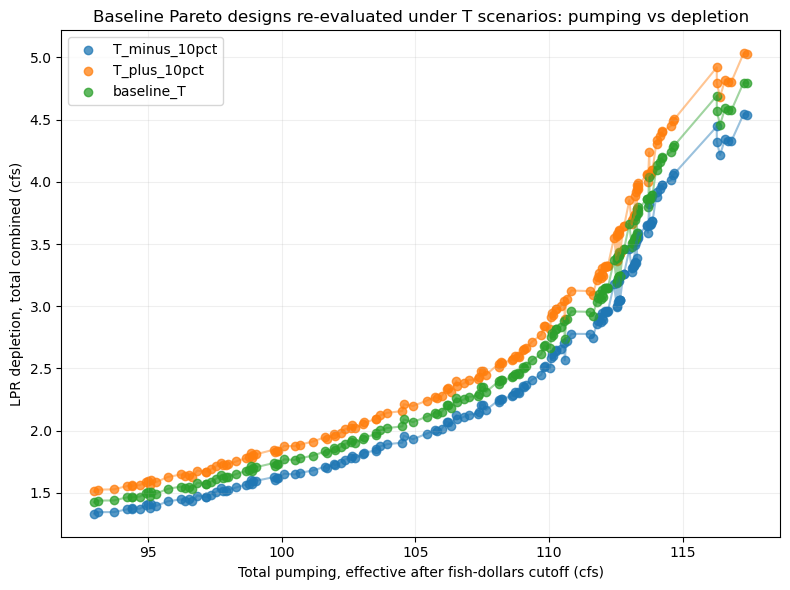

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_depletion_T_scenarios.png


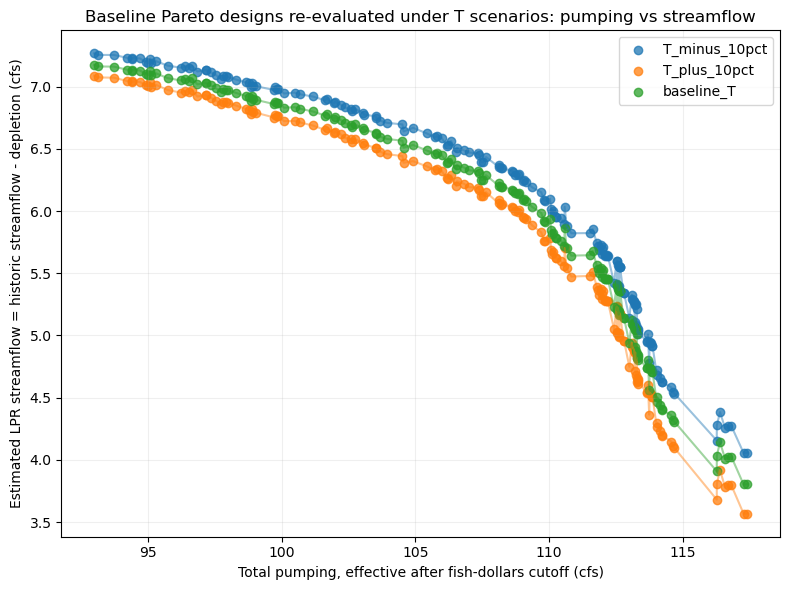

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_streamflow_T_scenarios.png


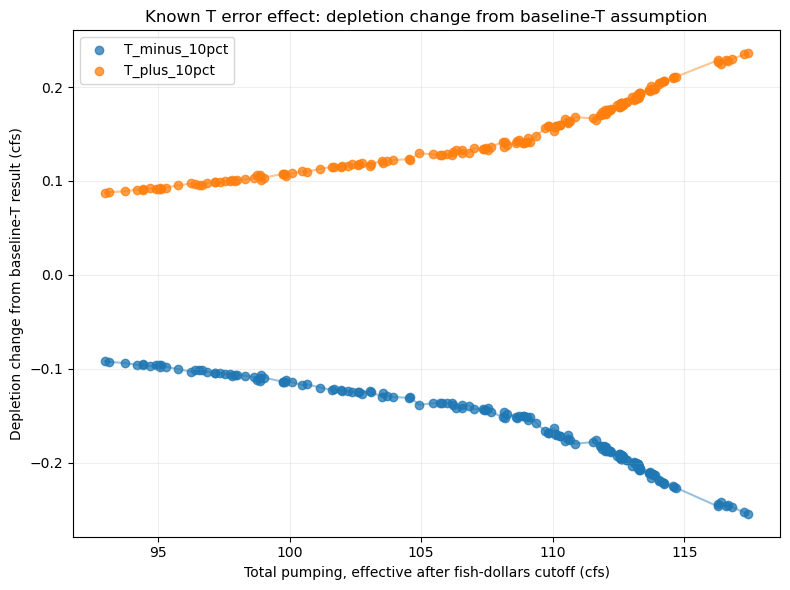

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_depletion_change_from_baseline_vs_pumping.png


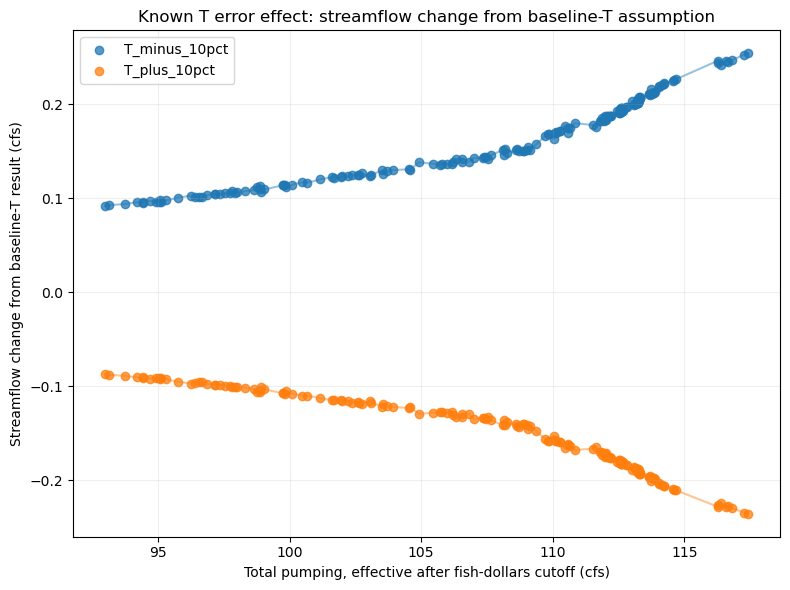

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_streamflow_change_from_baseline_vs_pumping.png


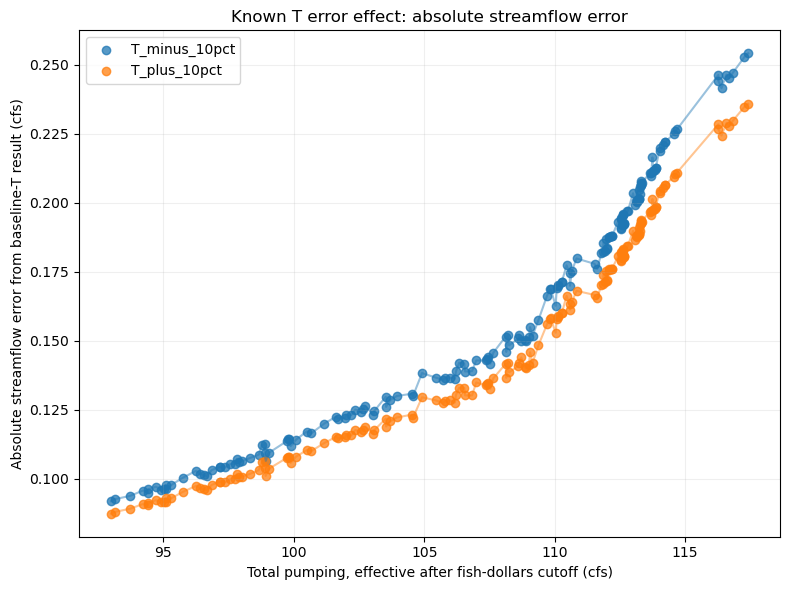

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_absolute_streamflow_error_vs_pumping.png


In [7]:
def sort_for_plot(df):
    return df.sort_values([PUMPING_COLUMN_FOR_HYDRO_PLOTS, "T_factor", "member"]).copy()


def plot_metric_by_scenario(df, ycol, ylabel, title, outfile):
    fig, ax = plt.subplots(figsize=(8, 6))

    for scenario_label, scenario_df in df.groupby("scenario"):
        scenario_df = sort_for_plot(scenario_df)
        ax.scatter(
            scenario_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            scenario_df[ycol],
            alpha=0.75,
            label=scenario_label,
        )
        ax.plot(
            scenario_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            scenario_df[ycol],
            alpha=0.45,
        )

    ax.set_xlabel("Total pumping, effective after fish-dollars cutoff (cfs)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend()
    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outfile)


plot_metric_by_scenario(
    results_long,
    "depletion_cfs",
    "LPR depletion, total combined (cfs)",
    "Baseline Pareto designs re-evaluated under T scenarios: pumping vs depletion",
    OUTPUT_DIR / "201_pumping_vs_depletion_T_scenarios.png",
)

plot_metric_by_scenario(
    results_long,
    "streamflow_cfs",
    "Estimated LPR streamflow = historic streamflow - depletion (cfs)",
    "Baseline Pareto designs re-evaluated under T scenarios: pumping vs streamflow",
    OUTPUT_DIR / "201_pumping_vs_streamflow_T_scenarios.png",
)

plot_metric_by_scenario(
    results_long.loc[results_long["scenario"] != baseline_label],
    "depletion_change_from_baseline_cfs",
    "Depletion change from baseline-T result (cfs)",
    "Known T error effect: depletion change from baseline-T assumption",
    OUTPUT_DIR / "201_depletion_change_from_baseline_vs_pumping.png",
)

plot_metric_by_scenario(
    results_long.loc[results_long["scenario"] != baseline_label],
    "streamflow_change_from_baseline_cfs",
    "Streamflow change from baseline-T result (cfs)",
    "Known T error effect: streamflow change from baseline-T assumption",
    OUTPUT_DIR / "201_streamflow_change_from_baseline_vs_pumping.png",
)

plot_metric_by_scenario(
    results_long.loc[results_long["scenario"] != baseline_label],
    "absolute_streamflow_error_cfs",
    "Absolute streamflow error from baseline-T result (cfs)",
    "Known T error effect: absolute streamflow error",
    OUTPUT_DIR / "201_absolute_streamflow_error_vs_pumping.png",
)

## 8) Save outputs

In [8]:
results_long.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_long.csv", index=False)
wide.to_csv(OUTPUT_DIR / "201_T_scenario_reevaluation_wide.csv", index=False)
summary.to_csv(OUTPUT_DIR / "201_T_scenario_summary.csv", index=False)

if not error_df.empty:
    error_df.to_csv(OUTPUT_DIR / "201_T_scenario_errors.csv", index=False)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f)

Saved files:
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_T_scenario_reevaluation_long.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_T_scenario_reevaluation_wide.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_T_scenario_summary.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_absolute_streamflow_error_vs_pumping.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_depletion_change_from_baseline_vs_pumping.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios/201_pumping_vs_depletion_T_scenarios.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reev

## 9) Interpretation guide

Use the baseline-T result as the modeler's assumed prediction.

Then read the ±10% results as:

> If the design was selected assuming the baseline transmissivity, but true transmissivity was actually ±10%, then this is how much the predicted depletion/streamflow would change.

A good project sentence might be:

> The baseline Pareto designs were re-evaluated under ±10% transmissivity perturbations. Total pumping remained unchanged because the pumping designs were fixed, but the predicted streamflow response changed because transmissivity affects the streamflow-depletion calculation.

Recommended next notebook:

`202_probability_weighted_T_uncertainty_cost.ipynb`

That notebook should replace the three discrete scenarios with a distribution of possible T values and calculate probability-weighted streamflow uncertainty/error for each baseline Pareto design.